Generating telemetry for 10000 EVs...
Dataset saved as 'ev_telemetry_dataset_v2.csv'.

Training LightGBM SoH Prediction Model...

----------------------------------------
Mean Absolute Error (MAE): 0.39% SoH
Root Mean Squared Error (RMSE): 0.49% SoH
R-Squared (R²): 0.6649
----------------------------------------


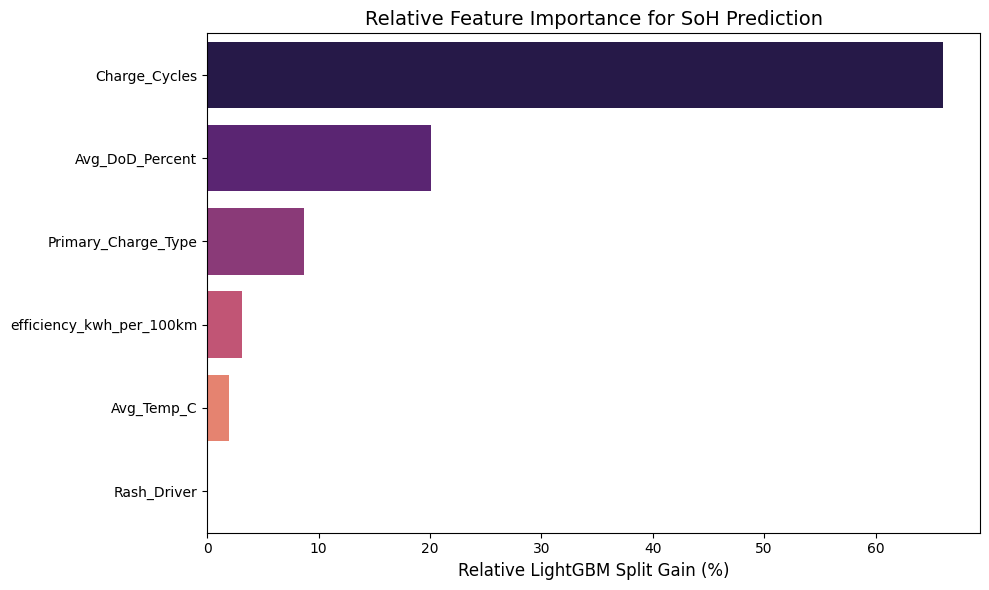


Preparing to download 'ev_telemetry_dataset_v2.csv' to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. DATA SIMULATION (Engineering Phase)
# ==========================================
np.random.seed(42)
num_vehicles = 10000

print(f"Generating telemetry for {num_vehicles} EVs...")

# Base vehicle attributes
vins = [f"VIN{str(i).zfill(5)}" for i in range(1, num_vehicles + 1)]

# EV Age: Normal distribution between 12 and 60 months
ages_normal = np.random.normal(loc=36, scale=10, size=num_vehicles)
vehicle_ages_months = np.clip(ages_normal, 12, 60).astype(int)

# Odometer: 500-1500 km/month using a Beta distribution
km_beta = np.random.beta(a=2.5, b=5, size=num_vehicles)
monthly_km = 500 + (km_beta * (1500 - 500))
odometer_km = vehicle_ages_months * monthly_km

# Charging behavior
primary_charge_type = np.random.choice(
    ['AC_Home_3kW', 'Mixed_11kW_30kW', 'DC_Fast_Over_30kW'],
    num_vehicles, p=[0.20, 0.30, 0.50]
)

# Ambient temperature
ambient_temp_c = np.random.normal(loc=24, scale=3.5, size=num_vehicles)
ambient_temp_c = np.clip(ambient_temp_c, 14.0, 31.0)

# ==========================================
# 2. DRIVER BEHAVIOR & PHYSICS-BASED CYCLES
# ==========================================
battery_capacity_kwh = 60.0

# Driver profiles
is_rash_driver = np.random.choice([True, False], size=num_vehicles, p=[0.10, 0.90])

# Energy efficiency
normal_efficiency = np.clip(np.random.normal(loc=12.5, scale=0.8, size=num_vehicles), 10.0, 15.0)
rash_efficiency = np.clip(np.random.normal(loc=20.0, scale=1.5, size=num_vehicles), 15.0, 25.0)
efficiency_kwh_per_100km = np.where(is_rash_driver, rash_efficiency, normal_efficiency)

# Depth of discharge
normal_dod = np.clip(np.random.normal(loc=20.0, scale=5.0, size=num_vehicles), 10.0, 30.0)
rash_dod = np.clip(np.random.normal(loc=88.0, scale=4.0, size=num_vehicles), 80.0, 95.0)
avg_depth_of_discharge = np.where(is_rash_driver, rash_dod, normal_dod)

# Physics-based charge cycles
total_energy_consumed_kwh = (odometer_km / 100.0) * efficiency_kwh_per_100km
charge_cycles = total_energy_consumed_kwh / battery_capacity_kwh

# ==========================================
# 3. PHYSICS-INSPIRED SoH CALCULATION
# ==========================================
base_soh = 100.0

# Penalties
cycle_penalty = charge_cycles * 0.015
temp_penalty = np.where(ambient_temp_c > 30, (ambient_temp_c - 30) * 0.2, 0)
dc_penalty = np.where(
    primary_charge_type == 'DC_Fast_Over_30kW', charge_cycles * 0.008,
    np.where(primary_charge_type == 'Mixed_11kW_30kW', charge_cycles * 0.004, 0)
)
dod_penalty = np.where(avg_depth_of_discharge > 80, (avg_depth_of_discharge - 80) * 0.1, 0)

# Final synthetic SoH
current_soh = base_soh - cycle_penalty - temp_penalty - dc_penalty - dod_penalty
current_soh += np.random.normal(0, 0.5, num_vehicles) # Natural variance
current_soh = np.clip(current_soh, 40, 100)

# ==========================================
# 4. BUILD DATASET
# ==========================================
df_ev = pd.DataFrame({
    'VIN': vins, 'Age_Months': vehicle_ages_months, 'Odometer_km': odometer_km,
    'efficiency_kwh_per_100km': efficiency_kwh_per_100km, 'Charge_Cycles': charge_cycles,
    'Avg_Temp_C': ambient_temp_c, 'Avg_DoD_Percent': avg_depth_of_discharge,
    'Primary_Charge_Type': primary_charge_type, 'Rash_Driver': is_rash_driver,
    'Target_SoH_Percent': current_soh
})

df_ev.to_csv('ev_telemetry_dataset_v2.csv', index=False)
print("Dataset saved as 'ev_telemetry_dataset_v2.csv'.\n")

# ==========================================
# 5. PREDICTIVE MODELING (LightGBM)
# ==========================================
print("Training LightGBM SoH Prediction Model...\n")

df_ev['Primary_Charge_Type'] = pd.Categorical(
    df_ev['Primary_Charge_Type'],
    categories=['AC_Home_3kW', 'Mixed_11kW_30kW', 'DC_Fast_Over_30kW']
)

X = df_ev.drop(columns=['VIN', 'Target_SoH_Percent', 'Odometer_km', 'Age_Months'])
y = df_ev['Target_SoH_Percent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

lgb_model = lgb.LGBMRegressor(n_estimators=150, learning_rate=0.05, max_depth=8, random_state=42, verbosity=-1)
lgb_model.fit(X_train, y_train, categorical_feature=['Primary_Charge_Type'])

# ==========================================
# 6. MODEL EVALUATION & VISUALIZATION
# ==========================================
y_pred = lgb_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("-" * 40)
print(f"Mean Absolute Error (MAE): {mae:.2f}% SoH")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}% SoH")
print(f"R-Squared (R²): {r2:.4f}")
print("-" * 40)

# Feature Importance Plot
importance_values = lgb_model.booster_.feature_importance(importance_type='gain')
importance_df = pd.DataFrame({'Feature': lgb_model.booster_.feature_name(), 'Importance_Gain': importance_values})
importance_df['Relative_Importance_%'] = (importance_df['Importance_Gain'] / importance_df['Importance_Gain'].sum()) * 100
importance_df = importance_df.sort_values(by='Relative_Importance_%', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Relative_Importance_%', y='Feature', hue='Feature', palette='magma', legend=False)
plt.title('Relative Feature Importance for SoH Prediction', fontsize=14)
plt.xlabel('Relative LightGBM Split Gain (%)', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

# ==========================================
# 7. GOOGLE COLAB FILE DOWNLOAD
# ==========================================
try:
    from google.colab import files
    print("\nPreparing to download 'ev_telemetry_dataset_v2.csv' to your computer...")
    files.download('ev_telemetry_dataset_v2.csv')
except ImportError:
    print("\nNot running in Colab. File is saved to local directory.")